In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv('/Users/macbookair/Desktop/Data Science Projects/Project3-StudentResult/bd_students_per_v2.csv')

In [3]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Yes,Private,95,Yes,95,98,92,94,98,Science
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,No,Semi_Govt,92,No,65,71,40,78,80,Commerce
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Yes,Govt,81,Yes,64,78,58,86,74,Commerce
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Yes,Private,90,Yes,84,90,85,86,88,Science
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Yes,Semi_Govt,75,Yes,54,70,45,79,76,Commerce


In [4]:
df.describe()

,id,age,family_size,studytime,attendance,english,math,science,social_science,art_culture
count,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000
mean,4307.500000,16.614375,4.502206,4.746168,74.027055,73.610427,72.938110,73.524036,74.465513,76.236066
std,2486.214593,0.969057,1.656726,2.185645,13.290046,15.343903,15.816147,15.115104,14.945846,13.619125
min,2.000000,10.000000,0.000000,1.000000,30.000000,18.000000,33.000000,33.000000,36.000000,36.000000
25%,2154.750000,16.000000,3.000000,3.000000,63.000000,64.000000,64.000000,63.000000,65.000000,69.000000
50%,4307.500000,17.000000,5.000000,5.000000,73.000000,75.000000,73.000000,75.000000,77.000000,76.000000
75%,6460.250000,17.000000,6.000000,6.000000,86.000000,85.000000,84.000000,85.000000,86.000000,86.000000
max,8613.000000,24.000000,11.000000,16.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           8612 non-null   int64 
 1   full_name                    8612 non-null   object
 2   age                          8612 non-null   int64 
 3   gender                       8612 non-null   object
 4   location                     8611 non-null   object
 5   family_size                  8612 non-null   int64 
 6   mother_education             8602 non-null   object
 7   father_education             8608 non-null   object
 8   mother_job                   8612 non-null   object
 9   father_job                   8612 non-null   object
 10  guardian                     8612 non-null   object
 11  parental_involvement         8612 non-null   object
 12  internet_access              8612 non-null   object
 13  studytime                    8612

In [6]:
df.isnull().sum()

id                              0
full_name                       0
age                             0
gender                          0
location                        1
family_size                     0
mother_education               10
father_education                4
mother_job                      0
father_job                      0
guardian                        0
parental_involvement            0
internet_access                 0
studytime                       0
tutoring                        0
school_type                     0
attendance                      0
extra_curricular_activities     0
english                         0
math                            0
science                         0
social_science                  0
art_culture                     0
stu_group                       0
dtype: int64

# Missing values imputation

In [7]:
df['mother_education'].value_counts()

mother_education
SSC             1492
HSC             1370
Diploma         1297
Under_SSC       1119
Non_Educated    1070
Honors          1061
Masters         1029
Hons             164
Name: count, dtype: int64

In [8]:
df['mother_education'] = df['mother_education'].fillna(df['mother_education'].mode()[0])

In [9]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       1
family_size                    0
mother_education               0
father_education               4
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
dtype: int64

In [10]:
df['father_education'].value_counts()

father_education
HSC             1345
SSC             1343
Masters         1286
Diploma         1259
Honors          1121
Non_Educated    1072
Under_SSC       1029
Hons             153
Name: count, dtype: int64

In [11]:
df['father_education'] = df['father_education'].fillna(df['father_education'].mode()[0])

In [12]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       1
family_size                    0
mother_education               0
father_education               0
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
dtype: int64

In [13]:
df['location'].value_counts()

location
City     2971
Urban    2874
Rural    2549
city      128
urban      89
Name: count, dtype: int64

In [14]:
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [15]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       0
family_size                    0
mother_education               0
father_education               0
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
dtype: int64

# Want to predict the impact of mother education on child result

In [16]:
df['average_marks'] = (
    df['english'] +
    df['math'] +
    df['science'] +
    df['social_science'] +
    df['art_culture']
) / 5

In [17]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Private,95,Yes,95,98,92,94,98,Science,95.4
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,Semi_Govt,92,No,65,71,40,78,80,Commerce,66.8
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Govt,81,Yes,64,78,58,86,74,Commerce,72.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Private,90,Yes,84,90,85,86,88,Science,86.6
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Semi_Govt,75,Yes,54,70,45,79,76,Commerce,64.8


In [18]:
df['mother_education'].value_counts()

mother_education
SSC             1502
HSC             1370
Diploma         1297
Under_SSC       1119
Non_Educated    1070
Honors          1061
Masters         1029
Hons             164
Name: count, dtype: int64

# visualization

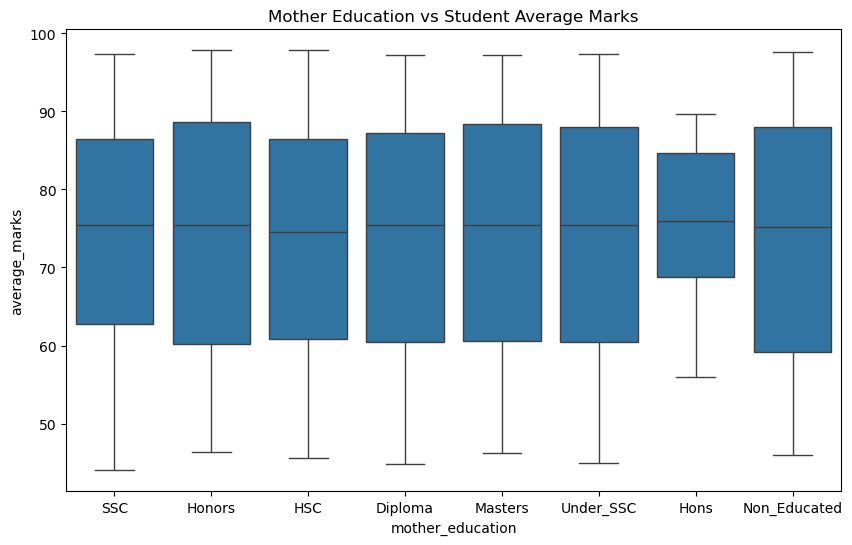

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='mother_education',
    y='average_marks',
    data=df
)

plt.title("Mother Education vs Student Average Marks")

plt.show()

“No strong relationship exists”

In [20]:
df.groupby('mother_education')['average_marks'].mean().sort_values()

mother_education
HSC             73.508467
Non_Educated    73.755140
Diploma         73.934927
Under_SSC       74.126899
SSC             74.303595
Masters         74.523226
Honors          74.848633
Hons            75.929268
Name: average_marks, dtype: float64

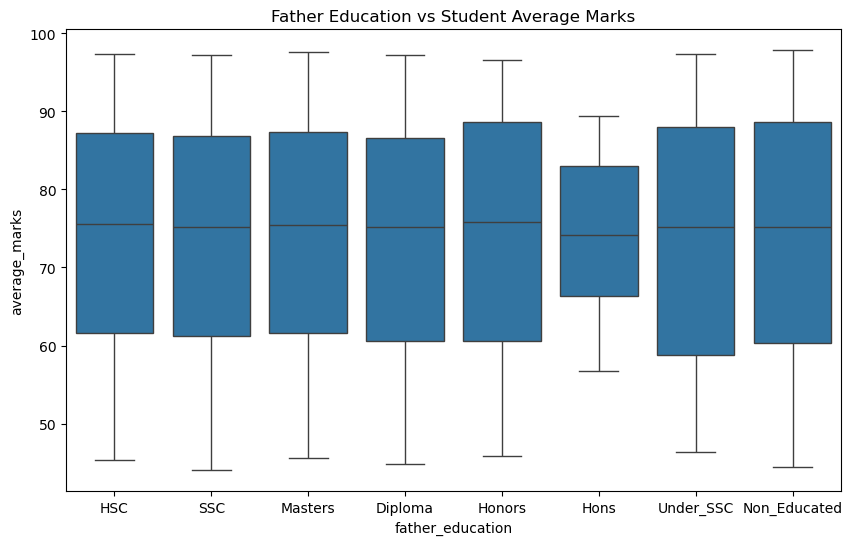

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='father_education',
    y='average_marks',
    data=df
)

plt.title("Father Education vs Student Average Marks")

plt.show()

Mother education alone does not significantly influence
student performance in this dataset.

# Predicting Student Academic Performance Using Family and Educational Background

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           8612 non-null   int64  
 1   full_name                    8612 non-null   object 
 2   age                          8612 non-null   int64  
 3   gender                       8612 non-null   object 
 4   location                     8612 non-null   object 
 5   family_size                  8612 non-null   int64  
 6   mother_education             8612 non-null   object 
 7   father_education             8612 non-null   object 
 8   mother_job                   8612 non-null   object 
 9   father_job                   8612 non-null   object 
 10  guardian                     8612 non-null   object 
 11  parental_involvement         8612 non-null   object 
 12  internet_access              8612 non-null   object 
 13  studytime         

In [23]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Private,95,Yes,95,98,92,94,98,Science,95.4
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,Semi_Govt,92,No,65,71,40,78,80,Commerce,66.8
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Govt,81,Yes,64,78,58,86,74,Commerce,72.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Private,90,Yes,84,90,85,86,88,Science,86.6
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Semi_Govt,75,Yes,54,70,45,79,76,Commerce,64.8


# Encode data


In [24]:
from  sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

df['mother_education'] = df['mother_education'].replace({'Hons': 'Honors'})
df['father_education'] = df['father_education'].replace({'Hons': 'Honors'})

In [25]:
encoder = OrdinalEncoder(categories=[['Non_Educated', 'Under_SSC', 'SSC', 'HSC', 'Diploma', 'Honors', 'Masters']])

# SSC             1502
# HSC             1370
# Diploma         1297
# Under_SSC       1119
# Non_Educated    1070
# Honors          1061
# Masters         1029
# Hons

In [26]:
df['mother_education_encoded'] = encoder.fit_transform(df[['mother_education']])
df['father_education_encoded'] = encoder.fit_transform(df[['father_education']])

In [27]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks,mother_education_encoded,father_education_encoded
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Yes,95,98,92,94,98,Science,95.4,2.0,3.0
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,No,65,71,40,78,80,Commerce,66.8,2.0,3.0
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Yes,64,78,58,86,74,Commerce,72.0,2.0,2.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Yes,84,90,85,86,88,Science,86.6,2.0,2.0
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Yes,54,70,45,79,76,Commerce,64.8,5.0,6.0


In [28]:


binary_cols = ['mother_job', 'father_job', 'parental_involvement',
               'internet_access', 'extra_curricular_activities','tutoring']  

In [29]:
df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})


/var/folders/4g/9m2h6m6x0lxbsngvlhdmn_dm0000gn/T/ipykernel_31567/3523292827.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})


In [30]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks,mother_education_encoded,father_education_encoded
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,0,0,...,1,95,98,92,94,98,Science,95.4,2.0,3.0
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,0,1,...,0,65,71,40,78,80,Commerce,66.8,2.0,3.0
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,1,1,...,1,64,78,58,86,74,Commerce,72.0,2.0,2.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,1,1,...,1,84,90,85,86,88,Science,86.6,2.0,2.0
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,0,1,...,1,54,70,45,79,76,Commerce,64.8,5.0,6.0


In [31]:
ohe_cols = ['gender', 'location', 'guardian', 'school_type', 'stu_group']
pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)

,id,full_name,age,family_size,mother_education,father_education,mother_job,father_job,parental_involvement,internet_access,...,location_urban,guardian_Father,guardian_Mother,guardian_Other,school_type_Govt,school_type_Private,school_type_Semi_Govt,stu_group_Arts,stu_group_Commerce,stu_group_Science
0,2,Avi Biswas,16,6,SSC,HSC,0,0,1,1,...,0,1,0,0,0,1,0,0,0,1
1,3,Taslima Sultana,18,6,SSC,HSC,0,1,1,0,...,0,1,0,0,0,0,1,0,1,0
2,4,Md Adilur Rahman,15,4,SSC,SSC,1,1,1,1,...,0,1,0,0,1,0,0,0,1,0
3,5,Saleh Ahmed,16,6,SSC,SSC,1,1,1,1,...,0,1,0,0,0,1,0,0,0,1
4,6,Din Islam,17,5,Honors,Masters,0,1,1,1,...,0,1,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8607,8609,Elina Khanam,17,5,HSC,Non_Educated,0,0,0,1,...,0,0,1,0,1,0,0,0,0,1
8608,8610,Sadiq Ghosh,16,2,SSC,Under_SSC,0,1,0,1,...,0,0,0,1,0,1,0,0,0,1
8609,8611,Arman Amin,18,3,Diploma,SSC,0,0,1,1,...,0,0,0,1,0,1,0,1,0,0
8610,8612,Tawhidul Saif,15,5,Honors,HSC,0,0,1,1,...,0,0,0,1,0,1,0,1,0,0


In [32]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks,mother_education_encoded,father_education_encoded
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,0,0,...,1,95,98,92,94,98,Science,95.4,2.0,3.0
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,0,1,...,0,65,71,40,78,80,Commerce,66.8,2.0,3.0
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,1,1,...,1,64,78,58,86,74,Commerce,72.0,2.0,2.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,1,1,...,1,84,90,85,86,88,Science,86.6,2.0,2.0
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,0,1,...,1,54,70,45,79,76,Commerce,64.8,5.0,6.0


In [33]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       0
family_size                    0
mother_education               0
father_education               0
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
average_marks                  0
mother_education_encoded       0
father_education_encoded       0
dtype: int64

In [34]:
y = df['average_marks']
X = df.drop(columns=['average_marks', 'id', 'english', 'math', 'science', 'social_science', 'art_culture',
                      'mother_education', 'father_education','full_name','stu_group','gender','location','guardian','school_type'])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

In [36]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
# ── See exactly which columns still have strings ──────────────────────────────
print(X_train.select_dtypes(include='object').columns.tolist())
print(X_train.select_dtypes(include='object').head(3))

[]
Empty DataFrame
Columns: []
Index: [5214, 4055, 2164]


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           8612 non-null   int64  
 1   full_name                    8612 non-null   object 
 2   age                          8612 non-null   int64  
 3   gender                       8612 non-null   object 
 4   location                     8612 non-null   object 
 5   family_size                  8612 non-null   int64  
 6   mother_education             8612 non-null   object 
 7   father_education             8612 non-null   object 
 8   mother_job                   8612 non-null   int64  
 9   father_job                   8612 non-null   int64  
 10  guardian                     8612 non-null   object 
 11  parental_involvement         8612 non-null   int64  
 12  internet_access              8612 non-null   int64  
 13  studytime         

In [39]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks,mother_education_encoded,father_education_encoded
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,0,0,...,1,95,98,92,94,98,Science,95.4,2.0,3.0
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,0,1,...,0,65,71,40,78,80,Commerce,66.8,2.0,3.0
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,1,1,...,1,64,78,58,86,74,Commerce,72.0,2.0,2.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,1,1,...,1,84,90,85,86,88,Science,86.6,2.0,2.0
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,0,1,...,1,54,70,45,79,76,Commerce,64.8,5.0,6.0


In [40]:
y_pred = model.predict(X_test)


In [41]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [42]:
from sklearn.metrics import mean_absolute_error

print(f"  MAE  : {mean_absolute_error(y_test, y_pred):.2f} marks")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"  R²   : {r2_score(y_test, y_pred):.4f}")


  MAE  : 3.85 marks
  RMSE : 5.25
  R²   : 0.8500


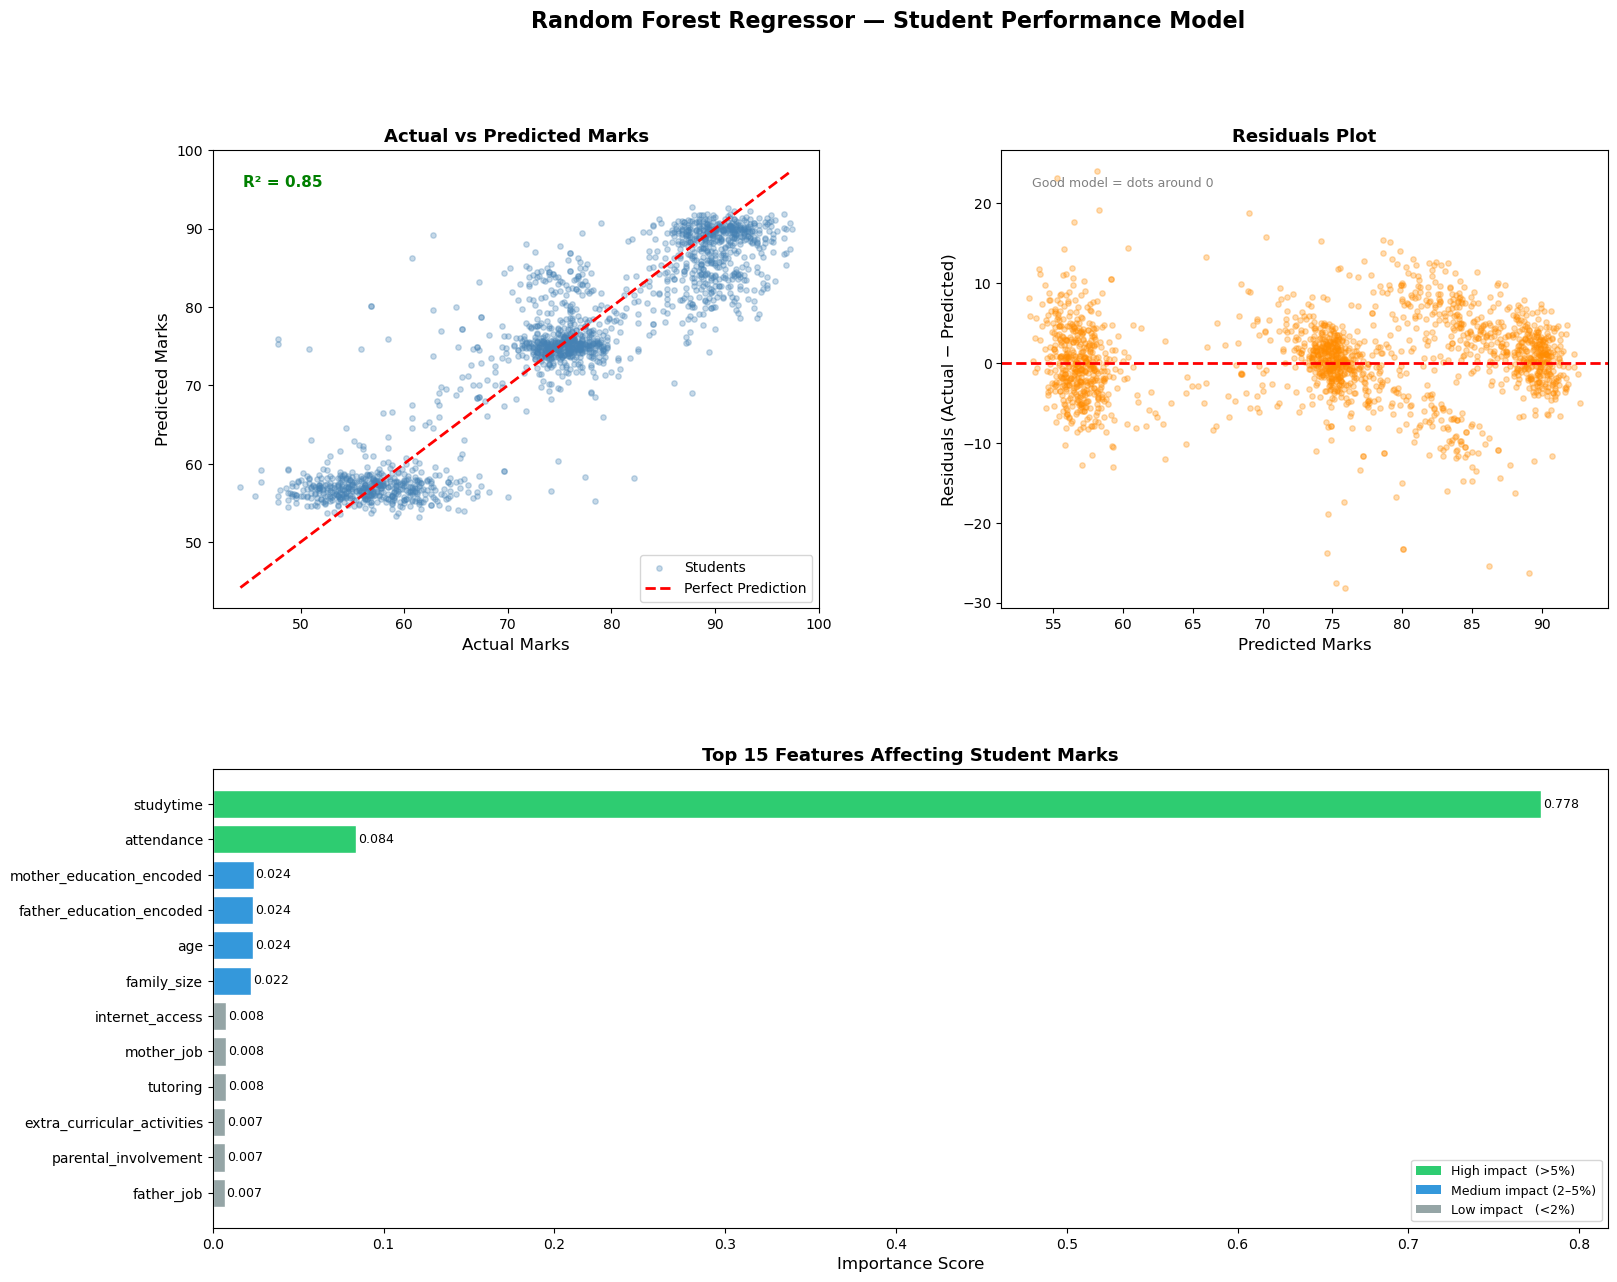

Saved as model_visualization.png


In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Random Forest Regressor — Student Performance Model", 
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=15, label='Students')
ax1.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel("Actual Marks", fontsize=12)
ax1.set_ylabel("Predicted Marks", fontsize=12)
ax1.set_title("Actual vs Predicted Marks", fontsize=13, fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, f'R² = 0.85', transform=ax1.transAxes,
         fontsize=11, color='green', fontweight='bold')

# ── 2. Residuals Plot ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
residuals = y_test.values - y_pred
ax2.scatter(y_pred, residuals, alpha=0.3, color='darkorange', s=15)
ax2.axhline(0, color='red', linestyle='--', lw=2)
ax2.set_xlabel("Predicted Marks", fontsize=12)
ax2.set_ylabel("Residuals (Actual − Predicted)", fontsize=12)
ax2.set_title("Residuals Plot", fontsize=13, fontweight='bold')
ax2.text(0.05, 0.92, 'Good model = dots around 0',
         transform=ax2.transAxes, fontsize=9, color='gray')

# ── 3. Feature Importance ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

colors = ['#2ecc71' if v > 0.05 else '#3498db' if v > 0.02 else '#95a5a6'
          for v in top15.values]

bars = ax3.barh(top15.index, top15.values, color=colors, edgecolor='white')
ax3.set_xlabel("Importance Score", fontsize=12)
ax3.set_title("Top 15 Features Affecting Student Marks", fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, top15.values):
    ax3.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='High impact  (>5%)'),
                   Patch(facecolor='#3498db', label='Medium impact (2–5%)'),
                   Patch(facecolor='#95a5a6', label='Low impact   (<2%)')]
ax3.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.savefig("model_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as model_visualization.png")

# Detect outlier

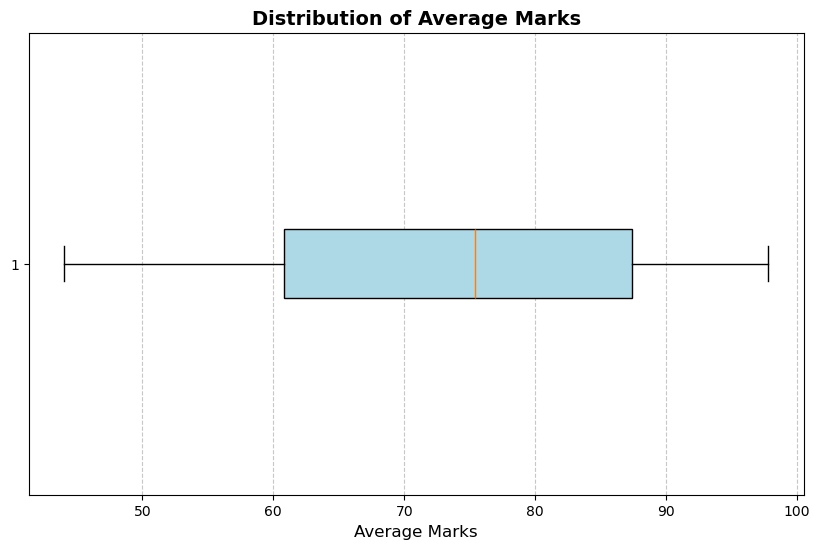

In [44]:
plt.figure(figsize=(10, 6))

plt.boxplot(df['average_marks'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Distribution of Average Marks", fontsize=14, fontweight='bold')
plt.xlabel("Average Marks", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)


Text(0.5, 0, 'Average Marks')

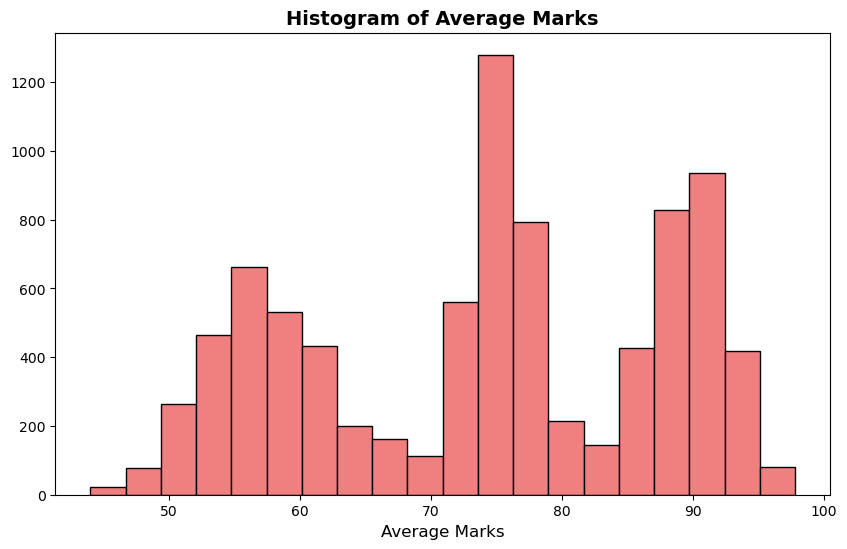

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(df['average_marks'], bins=20, color='lightcoral', edgecolor='black')
plt.title("Histogram of Average Marks", fontsize=14, fontweight='bold')
plt.xlabel("Average Marks", fontsize=12)


In [46]:
# Confirm with numbers
Q1  = df['average_marks'].quantile(0.25)
Q3  = df['average_marks'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['average_marks'] < lower) | (df['average_marks'] > upper)]

print(f"Q1          : {Q1:.2f}")
print(f"Q3          : {Q3:.2f}")
print(f"IQR         : {IQR:.2f}")
print(f"Lower bound : {lower:.2f}")
print(f"Upper bound : {upper:.2f}")
print(f"Outliers    : {len(outliers)} students")

Q1          : 60.80
Q3          : 87.40
IQR         : 26.60
Lower bound : 20.90
Upper bound : 127.30
Outliers    : 0 students
